# Project 20_Real Dataset

## Step 1_Let’s create a realistic dataset

In [6]:
import pandas as pd

data = {
    "Date": pd.date_range(start="2023-01-01", periods=12, freq="ME"),
    "Sales": [200, 220, 210, 250, 270, 300, 280, 310, 330, 360, 400, 420]
}

df_real = pd.DataFrame(data)

print(df_real)

         Date  Sales
0  2023-01-31    200
1  2023-02-28    220
2  2023-03-31    210
3  2023-04-30    250
4  2023-05-31    270
5  2023-06-30    300
6  2023-07-31    280
7  2023-08-31    310
8  2023-09-30    330
9  2023-10-31    360
10 2023-11-30    400
11 2023-12-31    420


## Step 2—Set Time Index & Plot

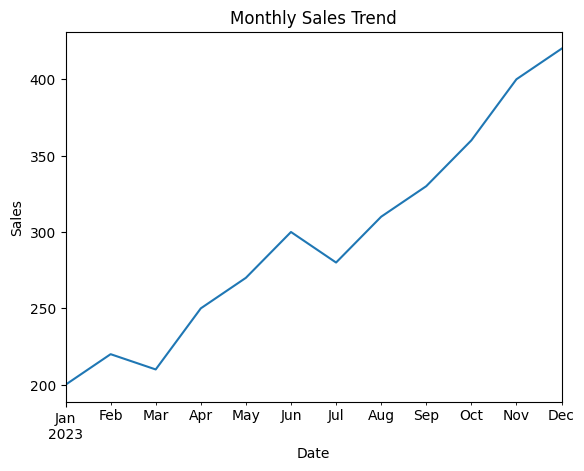

In [7]:
df_real.set_index("Date", inplace=True)

import matplotlib.pyplot as plt

df_real["Sales"].plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## Step 3 — Apply Moving Average on Real Data

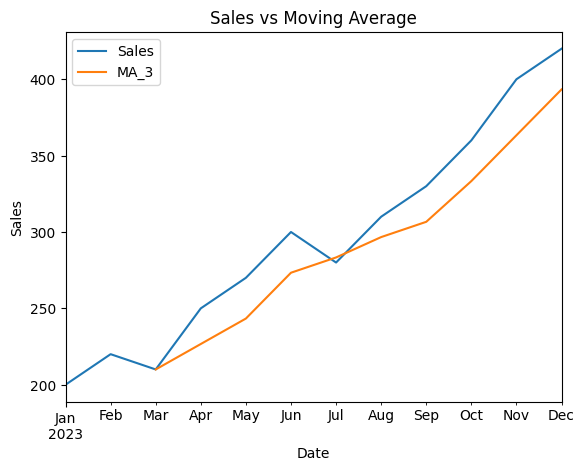

In [8]:
df_real["MA_3"] = df_real["Sales"].rolling(window=3).mean()

df_real[["Sales", "MA_3"]].plot()

import matplotlib.pyplot as plt
plt.title("Sales vs Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Step 4 — Final Forecast

In [9]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# Create time index
df_real["Time"] = np.arange(len(df_real))

# Train model
X = df_real[["Time"]]
y = df_real["Sales"]

model = LinearRegression()
model.fit(X, y)

# Predict next month (ONLY correct way)
pred = model.predict(pd.DataFrame([[12]], columns=["Time"]))

print(pred[0])

422.8787878787878


In [10]:
# save the data
df_real.to_csv("realistic_data.csv", index=False)